In [56]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import make_pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

In [57]:
fake = pd.read_csv("Dataset/Fake.csv")
real = pd.read_csv("Dataset/True.csv")

In [58]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [59]:
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [60]:
fake.info()

<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 60.4 MB


In [61]:
real.info()

<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 51.6 MB


In [62]:
fake.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [63]:
real.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [64]:
fake["label"] = 0
real["label"] = 1

In [65]:
df = pd.concat([fake, real], ignore_index=True)

In [66]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [67]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB


In [69]:
df["news"] = df["title"] + " " + df["text"]

In [70]:
df = df[["news", "label"]]

In [71]:
df.head()

,news,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


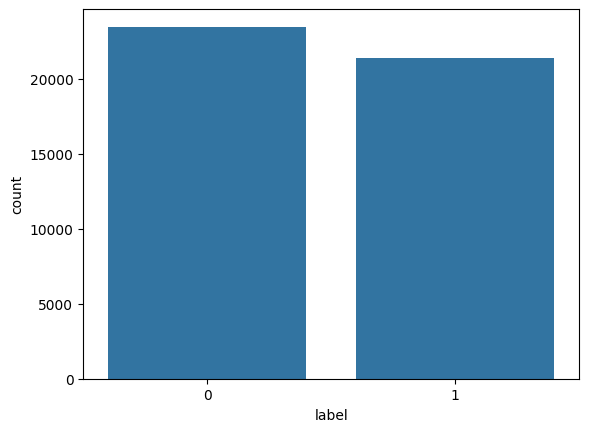

In [72]:
sns.countplot(
    data=df,
    x="label"
)

plt.show()

In [73]:
df["news_length"] = df["news"].apply(len)

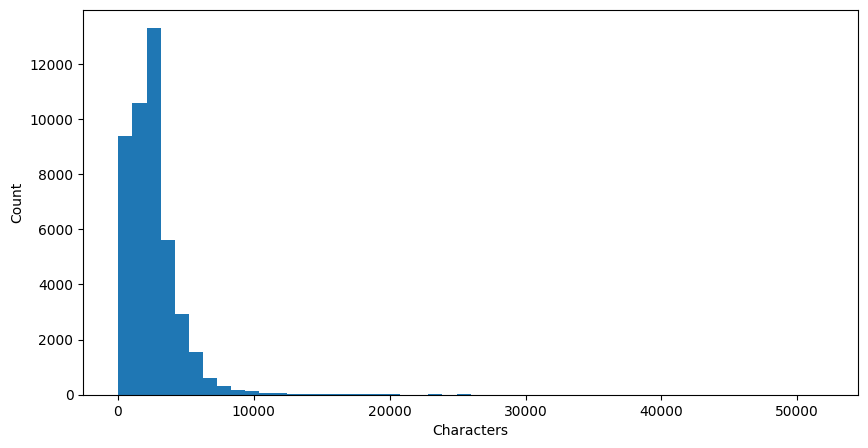

In [74]:
plt.figure(figsize=(10,5))

plt.hist(df["news_length"], bins=50)

plt.xlabel("Characters")

plt.ylabel("Count")

plt.show()

In [75]:
df["news"].head()

0    Ben Stein Calls Out 9th Circuit Court: Committ...
1    Trump drops Steve Bannon from National Securit...
2    Puerto Rico expects U.S. to lift Jones Act shi...
3     OOPS: Trump Just Accidentally Confirmed He Le...
4    Donald Trump heads for Scotland to reopen a go...
Name: news, dtype: str

In [76]:
df[["news", "news_length"]].sort_values(
    by="news_length",
    ascending=False
).head(5)

,news,news_length
10937,MEDIA TRIPWIRE? Ping Pong Pizza Conspiracy Pro...,51893
34710,MEDIA TRIPWIRE? Ping Pong Pizza Conspiracy Pro...,51893
6016,ANTI-AMERICAN GEORGE SOROS Locks Arms With NFL...,49766
30806,ANTI-AMERICAN GEORGE SOROS Locks Arms With NFL...,49766
3830,The Las Vegas Mass Shooting – More to the Stor...,48904


In [77]:
print(df.duplicated().sum())

5793


In [78]:
df = df.drop_duplicates(subset="news")
df = df.reset_index(drop=True)

In [79]:
print(df.duplicated().sum())

0


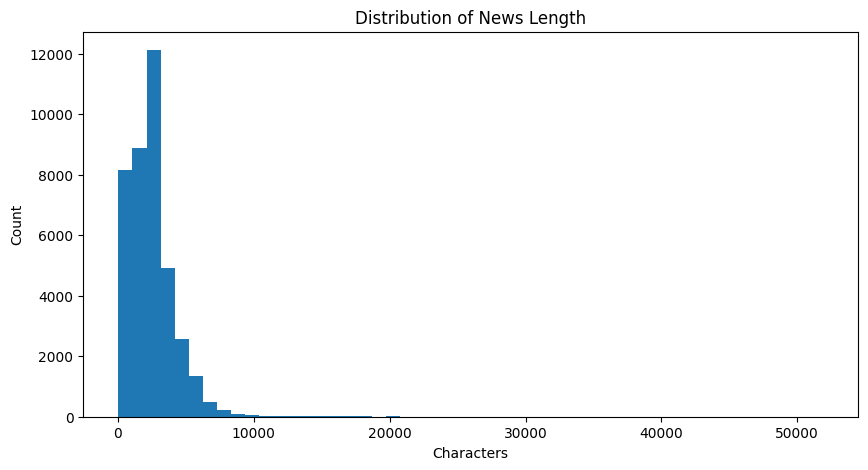

In [80]:
df["news_length"] = df["news"].apply(len)

plt.figure(figsize=(10,5))
plt.hist(df["news_length"], bins=50)
plt.xlabel("Characters")
plt.ylabel("Count")
plt.title("Distribution of News Length")
plt.show()

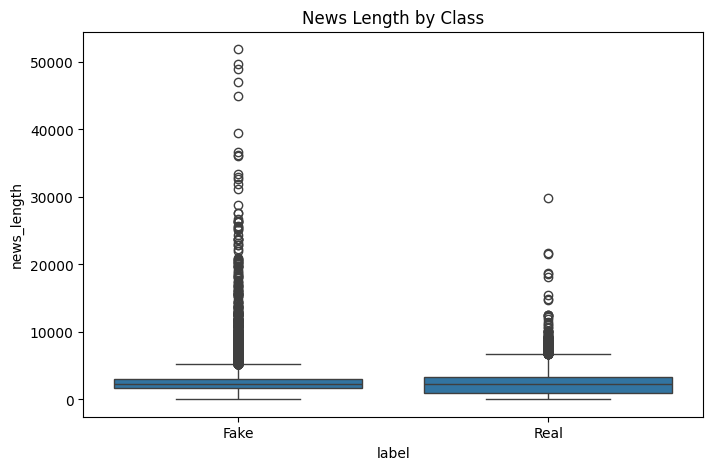

In [81]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="news_length"
)

plt.xticks([0,1], ["Fake","Real"])

plt.title("News Length by Class")

plt.show()

In [82]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [83]:
df["clean_news"] = df["news"].apply(clean_text)

In [84]:
for i in range(3):
    print("Original:\n")
    print(df["news"].iloc[i][:300])

    print("\nCleaned:\n")
    print(df["clean_news"].iloc[i][:300])

    print()

Original:

Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements 

Cleaned:

ben stein calls out th circuit court committed a ‘coup d’état’ against the constitution st century wire says ben stein reputable professor from pepperdine university also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off made some provocative statements on judge

Original:

Trump drops Steve Bannon from National Security Council WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year to give a political adviser an unprecedented role

Cleaned:

trump drops steve bannon from national security coun

In [85]:
X = df["clean_news"]
y = df["label"]

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [87]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(31284,)
(7821,)
(31284,)
(7821,)


In [88]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

In [89]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [90]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [91]:
model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [92]:
y_pred = model.predict(X_test_tfidf)

In [93]:
y_prob = model.predict_proba(X_test_tfidf)

In [94]:
print(y_prob[:5])

[[9.99083609e-01 9.16390585e-04]
 [9.62870612e-01 3.71293883e-02]
 [2.22232945e-03 9.97777671e-01]
 [2.64519613e-02 9.73548039e-01]
 [5.86839537e-03 9.94131605e-01]]


In [95]:
y_prob = y_prob[:, 1]

In [96]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

In [97]:
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.9870
Precision: 0.9848
Recall   : 0.9913
F1 Score : 0.9880
ROC AUC  : 0.9981


In [98]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake", "Real"]
))

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      3582
        Real       0.98      0.99      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



In [99]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3517   65]
 [  37 4202]]


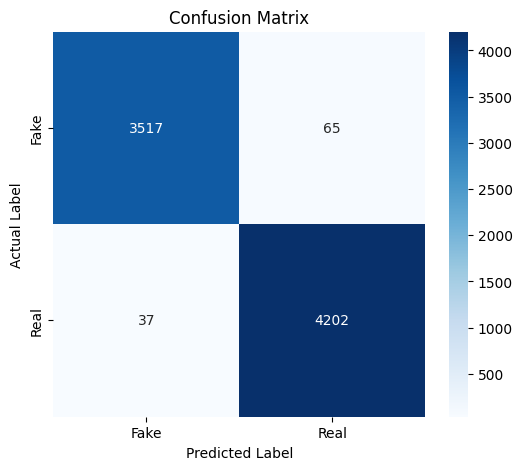

In [100]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

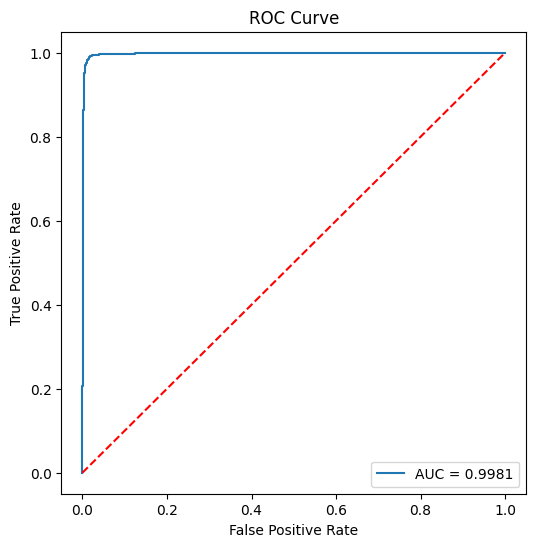

In [104]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [101]:
joblib.dump(model, "fake_news_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
